# ***Image Recognition Bootcamp***

### Day 1

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ssbakshi","key":"bf5fe8f34d0afb83e9c92fbfd2fc2307"}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [4]:
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files : ",path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files :  /kaggle/input/mnist-dataset


In [6]:
import tensorflow as tf
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.mnist.load_data()
print(f"Train shape : {X_train.shape}, Test shape : {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape : (60000, 28, 28), Test shape : (10000, 28, 28)


In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)
print(f"Train reshaped : {X_train.shape}")

Train reshaped : (60000, 28, 28, 1)


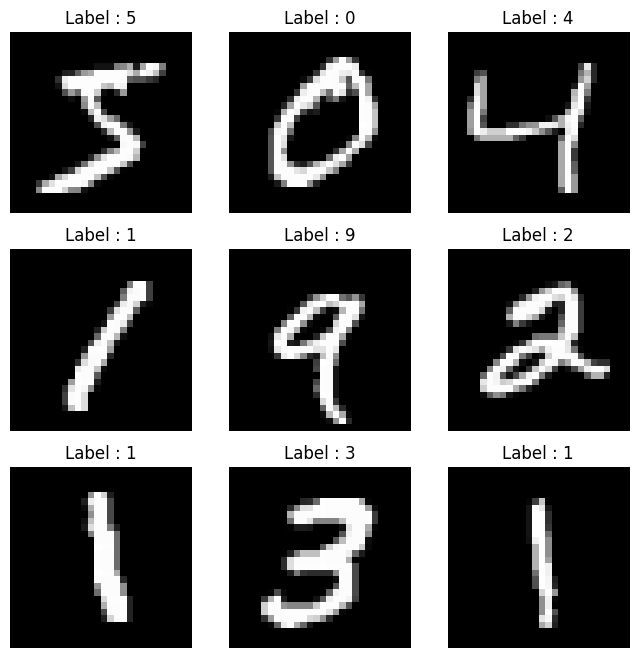

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize = (8,8))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_train[i].reshape(28,28),cmap="gray")
  plt.title(f"Label : {y_train[i]}")
  plt.axis('off')
plt.show()

In [9]:
(X_train_c10,y_train_c10),(X_test_c10,y_test_c10) = tf.keras.datasets.cifar10.load_data()
X_train_c10 = X_train_c10 / 255.0
X_test_c10 = X_test_c10 / 255.0
print(f'CIFAR 10 train shape : {X_train_c10.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
CIFAR 10 train shape : (50000, 32, 32, 3)


### Day 2

#### Using CNN

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation = 'relu'),
    Dense(10,activation = 'softmax')
])
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(X_train,y_train,epochs = 5,batch_size = 32,validation_split= 0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.8994 - loss: 0.3349 - val_accuracy: 0.9825 - val_loss: 0.0579
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9841 - loss: 0.0499 - val_accuracy: 0.9847 - val_loss: 0.0528
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9911 - loss: 0.0279 - val_accuracy: 0.9884 - val_loss: 0.0388
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9942 - loss: 0.0197 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9947 - loss: 0.0145 - val_accuracy: 0.9899 - val_loss: 0.0338


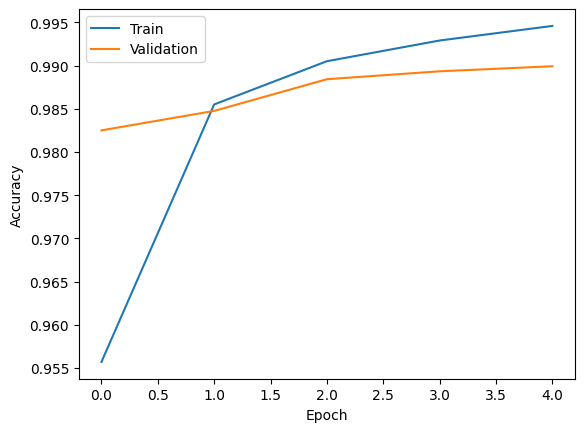

In [12]:
plt.plot(history.history['accuracy'],label = 'Train')
plt.plot(history.history['val_accuracy'],label = 'Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [13]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print(f'Test accuracy : {test_acc:.2f}')
y_pred = model.predict(X_test).argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9888 - loss: 0.0342
Test accuracy : 0.99
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [14]:
from tensorflow.keras.layers import Dropout
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (28,28,1)),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation = 'relu'),
    Dense(10,activation = 'softmax')
])
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.8828 - loss: 0.3714 - val_accuracy: 0.9783 - val_loss: 0.0702
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9812 - loss: 0.0608 - val_accuracy: 0.9864 - val_loss: 0.0472
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9875 - loss: 0.0382 - val_accuracy: 0.9883 - val_loss: 0.0371
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9913 - loss: 0.0265 - val_accuracy: 0.9871 - val_loss: 0.0443
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9916 - loss: 0.0244 - val_accuracy: 0.9898 - val_loss: 0.0389


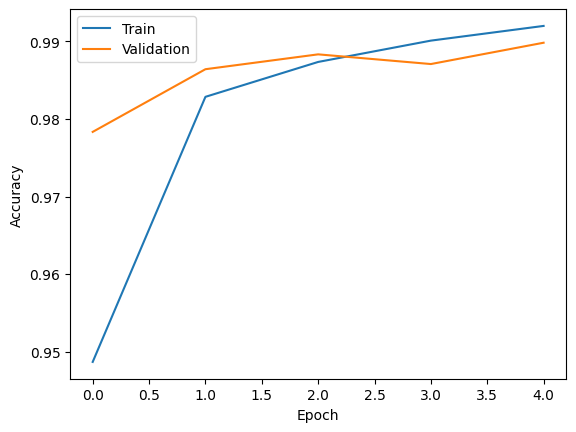

In [16]:
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [17]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print('Test Accuracy:{test_acc:.4f}')
y_pred = model.predict(X_test).argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9871 - loss: 0.0379
Test Accuracy:{test_acc:.4f}
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [18]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (28,28,1)),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation = 'relu'),
    Dense(10,activation = 'softmax')
])
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Day 3

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

datagen.fit(X_train_c10)

In [25]:
from tensorflow.keras.layers import BatchNormalization
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256,activation = 'relu'),
    Dropout(0.5),
    Dense(10,activation = 'softmax')
])
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
model.fit(datagen.flow(X_train_c10,y_train_c10,batch_size=32),epochs=10,validation_data=(X_test_c10,y_test_c10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 86ms/step - accuracy: 0.3430 - loss: 1.7773 - val_accuracy: 0.4927 - val_loss: 1.4444
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 0.5238 - loss: 1.3306 - val_accuracy: 0.5356 - val_loss: 1.3411
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.5748 - loss: 1.2019 - val_accuracy: 0.6086 - val_loss: 1.1400
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.6108 - loss: 1.1073 - val_accuracy: 0.5558 - val_loss: 1.3370
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 84ms/step - accuracy: 0.6304 - loss: 1.0579 - val_accuracy: 0.6465 - val_loss: 1.0015
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.6442 - loss: 1.0226 - val_accuracy: 0.6472 - val_loss: 0.9996
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 0.6606 - loss: 0.9817 - val_accuracy: 0.6832 - val_loss: 0.9207
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 83ms/step - accuracy: 0.6616 - lo

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1000
           1       0.78      0.88      0.83      1000
           2       0.71      0.49      0.58      1000
           3       0.52      0.52      0.52      1000
           4       0.85      0.43      0.58      1000
           5       0.65      0.57      0.61      1000
           6       0.65      0.86      0.74      1000
           7       0.67      0.79      0.72      1000
           8       0.82      0.83      0.82      1000
           9       0.68      0.88      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.69     10000
weighted avg       0.71      0.70      0.69     10000



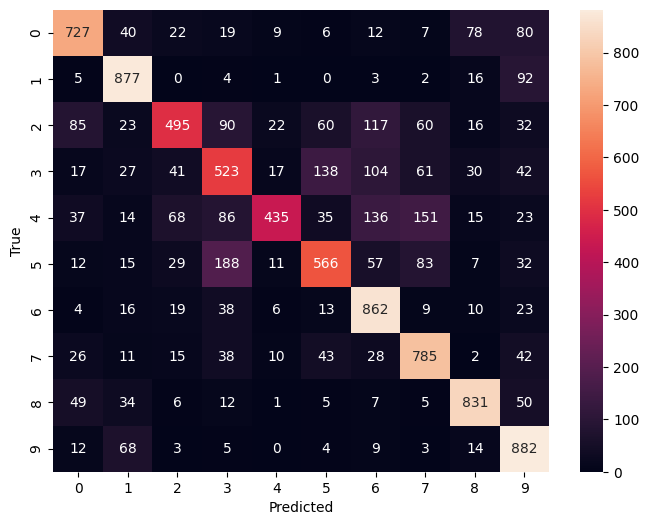

In [26]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
y_pred_c10 = model.predict(X_test_c10).argmax(axis=1)
cm = confusion_matrix(y_test_c10,y_pred_c10)
print(classification_report(y_test_c10,y_pred_c10))

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Day 4


In [28]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 52% 114M/218M [00:00<00:00, 1.19GB/s]
100% 218M/218M [00:00<00:00, 528MB/s] 


In [31]:
import zipfile
with zipfile.ZipFile('/content/cat-and-dog.zip','r')as zip_ref:
  zip_ref.extractall('/content/dogs-vs-cats')

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_generator = datagen.flow_from_directory('/content/dogs-vs-cats',target_size=(224,224),batch_size=32,class_mode='binary',subset='training')
val_generator = datagen.flow_from_directory('/content/dogs-vs-cats',target_size=(224,224),batch_size=32,class_mode='binary',subset='validation')

Found 8023 images belonging to 2 classes.
Found 2005 images belonging to 2 classes.


In [33]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

base_model = MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False

model = Sequential([base_model,GlobalAveragePooling2D(),Dense(128,activation='relu'),Dense(1,activation='sigmoid')])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_generator,epochs=5,validation_data=val_generator)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - accuracy: 0.7809 - loss: 0.5569 - val_accuracy: 0.7985 - val_loss: 0.5075
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - accuracy: 0.7985 - loss: 0.4988 - val_accuracy: 0.7985 - val_loss: 0.5111
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - accuracy: 0.7900 - loss: 0.5019 - val_accuracy: 0.7985 - val_loss: 0.5086
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.7945 - loss: 0.4855 - val_accuracy: 0.7985 - val_loss: 0.5121
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.7953 - loss: 0.4681 - val_accuracy: 0.7985 - val_loss: 0.5345


In [34]:
base_model.trainable=True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_generator,epochs=3,validation_data=val_generator)

Epoch 1/3
251/251 ━━━━━━━━━━━━━━━━━━━━ 1946s 8s/step - accuracy: 0.7979 - loss: 0.4945 - val_accuracy: 0.7985 - val_loss: 0.5273
Epoch 2/3
251/251 ━━━━━━━━━━━━━━━━━━━━ 1712s 7s/step - accuracy: 0.8067 - loss: 0.4412 - val_accuracy: 0.7985 - val_loss: 0.5255
Epoch 3/3
251/251 ━━━━━━━━━━━━━━━━━━━━ 1791s 7s/step - accuracy: 0.8066 - loss: 0.4275 - val_accuracy: 0.7970 - val_loss: 0.5254


In [35]:
model.save('mobilenet_cats_dogs.h5')
# To load
import tensorflow as tf
linear_model = tf.keras.models.load_model('mobilenet_cats_dogs.h5')

63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step


/tmp/ipython-input-2979471410.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


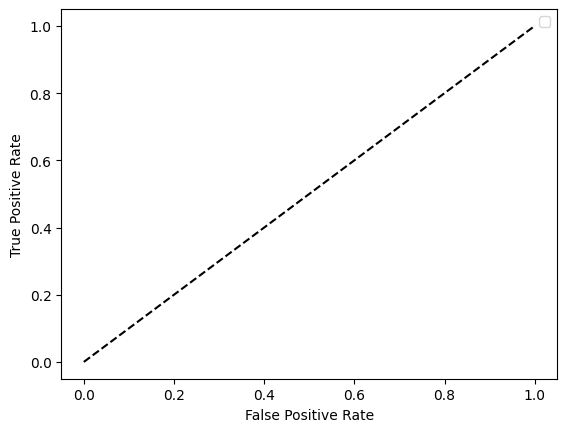

In [37]:
from sklearn.metrics import roc_curve,auc
y_pred_proba = linear_model.predict(val_generator)
fpr,tpr,_ = roc_curve(val_generator.classes,y_pred_proba)
roc_auc = auc(fpr,tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Day 5

In [40]:
from google.colab import files
uploaded = files.upload()

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

img_path = 'pexels-photo-1170986.jpeg'  # Replace with your filename
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = linear_model.predict(img_array)
print("Predicted class:", "Dog" if prediction[0][0] > 0.5 else "Cat")

Saving pexels-photo-1170986.jpeg to pexels-photo-1170986 (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted class: Dog


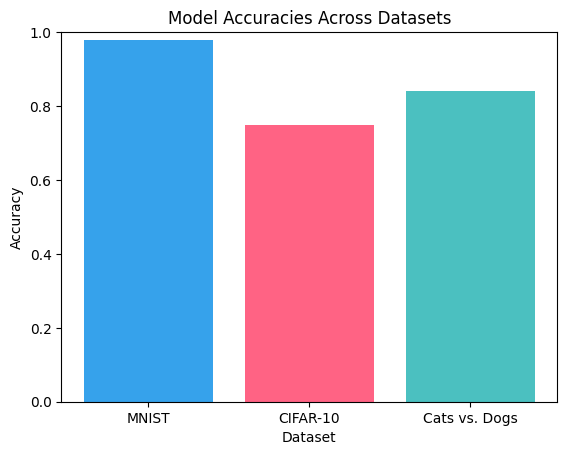

In [41]:
import matplotlib.pyplot as plt
datasets = ['MNIST', 'CIFAR-10', 'Cats vs. Dogs']
accuracies = [0.98, 0.75, 0.84]
plt.bar(datasets, accuracies, color=['#36A2EB', '#FF6384', '#4BC0C0'])
plt.title('Model Accuracies Across Datasets')
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()